# Video Game Sales & Metacritic Intelligence 1980–26

50 000 видеоигр, выпущенных с 1985 по 2026 год.  
Содержит информацию о платформах, жанрах, издателях, оценках Metacritic, продажах и функциях игр.

Загрузка библиотек и настройка размеров

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

Загрузка датасета и вывод первых десяти значений



In [179]:
df = pd.read_csv('../data/games.csv')
df.head(10)

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,global_sales_million,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
0,G000001,eFootball 2023,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver,Poland,AAA,M,69,6.7,34,1172,10.01,8.35,2.58,3.46,24.40,575.88,49.99,1,1,1,0,0,0,0,0,0,31.8,86.1
1,G000002,Doom 3,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft,France,AAA,M,78,9.4,5,186,52.28,33.72,5.32,12.30,103.62,5056.51,59.99,1,0,1,1,0,0,0,0,0,13.1,55.4
2,G000003,God of Fire,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios,USA,AAA,T,76,6.6,33,363,2.90,1.48,0.75,0.91,6.04,138.60,59.99,0,0,0,0,0,0,0,0,0,9.8,20.9
3,G000004,Call of Duty: Rising Sun,Mobile (Android),Mobile,Google,0,Shooter,2017,InXile Entertainment,InXile Entertainment,USA,AA,M,62,7.0,28,532,6.76,3.27,0.73,2.34,13.10,36.98,0.00,0,1,1,1,0,0,0,0,0,9.1,44.8
4,G000005,Fortnite 3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software,USA,AAA,AO,62,5.6,58,1280,25.12,15.94,7.02,7.71,55.79,2148.24,69.99,1,1,0,1,0,0,0,0,0,150.8,322.3
5,G000006,Need for Speed: Shadow War,PC,PC,Various,0,Racing,2003,2K Games,id Software,USA,AAA,E,68,7.1,13,26,7.17,6.28,2.01,2.77,18.23,317.90,59.99,0,0,1,0,0,0,0,0,0,14.1,37.7
6,G000007,Valorant 3,NES,Console,Nintendo,3,Shooter,1993,Activision Blizzard,Activision Blizzard,USA,AAA,T,90,8.5,72,109,58.72,39.21,6.14,7.42,111.49,3820.21,79.99,1,1,1,0,0,0,0,1,0,12.6,62.1
7,G000008,FIFA 2024,NES,Console,Nintendo,3,Sports,1990,Sega,Obsidian Entertainment,Japan,AAA,T,75,7.8,9,280,17.44,7.64,14.14,5.06,44.28,2121.46,59.99,1,1,1,0,0,0,0,0,0,14.5,30.1
8,G000009,Battlefield Odyssey,Xbox 360,Console,Microsoft,7,Shooter,2005,Humble Games,Humble Games,USA,Indie,E10+,67,7.0,3,224,1.69,1.47,0.37,0.39,3.92,163.29,49.99,0,1,0,1,0,0,0,0,0,4.2,17.6
9,G000010,Kirby's Knight,Atari 2600,Console,Atari,2,Platform,1990,2K Games,Epic Games,USA,AAA,M,75,8.1,15,182,6.65,4.93,1.80,0.74,14.12,653.65,49.99,0,0,1,0,0,0,0,0,0,15.1,64.1




### 1.1. Описание признаков

### Идентификаторы (2)
- game_id — уникальный код игры 
- title — название игры

### Платформа (4)
- platform — название платформы (PS5, Xbox, Switch, PC…)
- platform_type — тип (Console / Handheld / PC / Mobile / Hybrid / Streaming)
- platform_maker — производитель (Sony, Microsoft, Nintendo…)
- platform_generation — поколение консоли (1–10)

### Игра (3)
- genre — жанр (Action, Sports, Shooter, RPG…)
- year — год выпуска (1985–2026)
- how_long_to_beat_main_hrs / how_long_to_beat_completionist_hrs — время прохождения

### Издатель и разработчик (4)
- publisher, developer — издатель и студия
- publisher_region, publisher_tier — регион и уровень (AAA / AA / Indie)
- esrb_rating — возрастной рейтинг 

### Оценки (4)
- metacritic_score — оценка критиков (0–100)
- user_score — оценка игроков (0.0–10.0)
- critic_review_count, user_review_count — число рецензий

### Продажи (7)
- na_sales_million, eu_sales_million, jp_sales_million, other_sales_million
- global_sales_million — сумма четырёх регионов
- estimated_revenue_million_usd — оценочная выручка
- launch_price_usd — цена на старте

### Бинарные функции игры (9)
- is_sequel, online_multiplayer, dlc_released, microtransactions,
  loot_boxes, game_pass_available, vr_support,
  goty_nominated, goty_won

**Целевая переменная:** `global_sales_million` — предсказание мировых продаж (регрессия).

Признаки: платформа, жанр, издатель, оценки, время прохождения, функции игры. Региональные продажи (na/eu/jp/other) исключаются из признаков — они прямо связаны с целевой и создадут утечку.

### 1.2 Основные статистики

In [180]:
df.info(show_counts=True)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   game_id                             50000 non-null  object 
 1   title                               50000 non-null  object 
 2   platform                            50000 non-null  object 
 3   platform_type                       50000 non-null  object 
 4   platform_maker                      50000 non-null  object 
 5   platform_generation                 50000 non-null  int64  
 6   genre                               50000 non-null  object 
 7   year                                50000 non-null  int64  
 8   publisher                           50000 non-null  object 
 9   developer                           50000 non-null  object 
 10  publisher_region                    50000 non-null  object 
 11  publisher_tier                      50000

,platform_generation,year,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,global_sales_million,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,4.397120,2007.479640,74.046480,7.407888,27.290160,470.612300,11.946759,7.732016,3.370298,2.985665,26.034738,639.163523,42.028854,0.412100,0.506960,0.623140,0.310980,0.065020,0.036520,0.024420,0.044640,0.006760,24.84839,87.036108
std,3.256757,11.673832,8.626383,1.160381,26.261779,894.567299,20.717035,13.477750,7.439700,5.634561,45.035430,1103.970191,24.769804,0.492218,0.499957,0.484604,0.462899,0.246564,0.187582,0.154351,0.206514,0.081942,34.73811,126.802256
min,0.000000,1985.000000,37.000000,2.200000,0.000000,0.000000,0.030000,0.010000,0.000000,0.010000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,2.000000
25%,0.000000,1998.000000,68.000000,6.600000,11.000000,91.000000,2.420000,1.510000,0.400000,0.540000,5.140000,92.590000,19.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.00000,29.400000
50%,5.000000,2008.000000,74.000000,7.400000,20.000000,221.000000,5.940000,3.760000,1.210000,1.380000,12.795000,294.835000,39.990000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.20000,46.100000
75%,7.000000,2017.000000,80.000000,8.200000,34.000000,515.000000,13.420000,8.632500,3.330000,3.260000,29.290000,750.355000,59.990000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.10000,85.200000
max,10.000000,2026.000000,99.000000,10.000000,636.000000,39129.000000,769.070000,389.100000,251.210000,300.560000,1494.680000,45686.500000,79.990000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,377.50000,1685.000000


### 1.3 Приведение типов

In [181]:
# Object-столбцы с повторяющимися категориями
# game_id и title НЕ трогаем — это идентификаторы
cat_cols = [
    'platform',           
    'platform_type',      
    'platform_maker',     
    'genre',              
    'publisher',          
    'developer',          
    'publisher_region',   
    'publisher_tier',     
    'esrb_rating',        
]

for col in cat_cols:
    df[col] = df[col].astype('category')


In [182]:
int8_cols = [
    'platform_generation',   # 0–10
    'metacritic_score',      # 37–99
    'is_sequel',             
    'online_multiplayer',    
    'dlc_released',          
    'microtransactions',     
    'loot_boxes',            
    'game_pass_available',   
    'vr_support',           
    'goty_nominated',        
    'goty_won',              
]

int16_cols = [
    'year',                  # 1985–2026
    'critic_review_count',   # 0–636
]

int32_cols = [
    'user_review_count',     
]

for col in int8_cols:
    df[col] = df[col].astype('int8')
for col in int16_cols:
    df[col] = df[col].astype('int16')
for col in int32_cols:
    df[col] = df[col].astype('int32')


In [183]:
float_cols = [
    'user_score',                          
    'na_sales_million',                    
    'eu_sales_million',                    
    'jp_sales_million',                   
    'other_sales_million',                 
    'global_sales_million',                
    'estimated_revenue_million_usd',       
    'launch_price_usd',                    
    'how_long_to_beat_main_hrs',           
    'how_long_to_beat_completionist_hrs',  
]

for col in float_cols:
    df[col] = df[col].astype('float32')

In [184]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   game_id                             50000 non-null  object  
 1   title                               50000 non-null  object  
 2   platform                            50000 non-null  category
 3   platform_type                       50000 non-null  category
 4   platform_maker                      50000 non-null  category
 5   platform_generation                 50000 non-null  int8    
 6   genre                               50000 non-null  category
 7   year                                50000 non-null  int16   
 8   publisher                           50000 non-null  category
 9   developer                           50000 non-null  category
 10  publisher_region                    50000 non-null  category
 11  publisher_tier              

In [185]:
# Категориальные столбцы (кроме game_id и title — это идентификаторы)
cat_features = df.select_dtypes(include=['category']).columns.to_list()

# Числовые столбцы
num_features = df.select_dtypes(include=['number']).columns.to_list()

print(f'Категориальные ({len(cat_features)}):')
print(cat_features)
print()
print(f'Числовые ({len(num_features)}):')
print(num_features)

Категориальные (9):
['platform', 'platform_type', 'platform_maker', 'genre', 'publisher', 'developer', 'publisher_region', 'publisher_tier', 'esrb_rating']

Числовые (24):
['platform_generation', 'year', 'metacritic_score', 'user_score', 'critic_review_count', 'user_review_count', 'na_sales_million', 'eu_sales_million', 'jp_sales_million', 'other_sales_million', 'global_sales_million', 'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel', 'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes', 'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won', 'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs']


### 1.4 Удаление идентификаторов

In [186]:
# Убираем game_id и title — они не несут информации для модели
df = df.drop(columns=['game_id', 'title'])
df.shape

(50000, 33)

In [187]:
for cat in cat_features:
    print(f'{cat}: {df[cat].nunique()} уникальных')

platform: 33 уникальных
platform_type: 7 уникальных
platform_maker: 8 уникальных
genre: 20 уникальных
publisher: 51 уникальных
developer: 51 уникальных
publisher_region: 15 уникальных
publisher_tier: 3 уникальных
esrb_rating: 6 уникальных


In [188]:
for cat in ['platform', 'genre', 'publisher', 'publisher_tier']:
    print(f'--- {cat} ---')
    print(df[cat].value_counts().head(15))
    print()

--- platform ---
platform
PC                  6305
NES                 3045
Mobile (iOS)        2622
Mobile (Android)    2483
Browser             2455
Game Boy            2107
SNES                1906
Nintendo Switch     1737
PlayStation         1727
Atari 2600          1607
Sega Genesis        1555
PlayStation 2       1540
PlayStation 4       1492
PlayStation 3       1305
Xbox Series X/S     1300
Name: count, dtype: int64

--- genre ---
genre
Action              7496
Sports              5571
Shooter             4741
Role-Playing        4267
Platform            3384
Racing              3371
Simulation          3249
Fighting            2761
Adventure           2397
Puzzle              2308
Action-Adventure    1985
Misc                1896
Strategy            1859
MMORPG               959
Survival Horror      956
Name: count, dtype: int64

--- publisher ---
publisher
Sega                    1560
Sony Interactive        1552
Bandai Namco            1536
FromSoftware            1520
id Sof

## 2. Очистка данных

### 2.1 Проверки 

In [189]:
# Проверки
print('Пропуски:',            df.isnull().sum().sum())
print('Дубликаты:',           df.duplicated().sum())
print('Сумма регионов ≠ global:',
      (df['global_sales_million']
       - df[['na_sales_million','eu_sales_million',
             'jp_sales_million','other_sales_million']].sum(axis=1)
      ).abs().gt(0.01).sum())
print('Год вне [1985, 2026]:',    (~df['year'].between(1985, 2026)).sum())
print('metacritic вне [0, 100]:', (~df['metacritic_score'].between(0, 100)).sum())
print('user_score вне [0, 10]:',  (~df['user_score'].between(0, 10)).sum())
print('Отрицательные значения:',  int((df.select_dtypes('number') < 0).any().any()))

Пропуски: 0
Дубликаты: 0
Сумма регионов ≠ global: 0
Год вне [1985, 2026]: 0
metacritic вне [0, 100]: 0
user_score вне [0, 10]: 0
Отрицательные значения: 0


Все проверки пройдены. Данные валидны — удаление строк не требуется.


### 2.2. Отсечения

Убираем записи, не относящиеся к задаче предсказания продаж
премиум-игр: free-to-play (другая модель монетизации),
игры без продаж и без отзывов.

In [190]:
n_before = len(df)

df = (
    df
    .query('launch_price_usd > 0')                             # убираем F2P
    .query('global_sales_million > 0')                         # убираем нулевые продажи
    .query('critic_review_count > 0 or user_review_count > 0') # убираем игры без отзывов
    .reset_index(drop=True)
)

print(f'Было:  {n_before}')
print(f'Стало: {len(df)}')
print(f'Убрано: {n_before - len(df)} ({100*(n_before - len(df))/n_before:.2f}%)')

Было:  50000
Стало: 46032
Убрано: 3968 (7.94%)


### 2.3. Заметка для этапа моделирования

Столбцы `na/eu/jp/other_sales_million` в сумме дают целевую
`global_sales_million`. Их использование как признаков приведёт к
утечке данных (data leakage): модель выучит формулу сложения вместо
реальных зависимостей. То же — для `estimated_revenue_million_usd`.

Эти 5 столбцов будут исключены **перед обучением модели**
(раздел «Подготовка признаков», ЛР2). Сейчас их не трогаем — они
нужны для анализа региональных продаж в следующем разделе.

**Вывод:**

- Все проверки пройдены: пропусков 0, дубликатов 0, сумма регионов
  совпадает с `global_sales_million`, диапазоны корректны — критичных
  строк для удаления нет.
- Отсечение убрало 3 968 записей (7.94%) — только free-to-play игры
  (`launch_price_usd == 0`). Фильтры по продажам и отзывам ничего
  не убрали (данные изначально валидны).
- Осталось **46 032 строки** для дальнейшего анализа.

## 3. Анализ признаков для модели



### 3.1. Распределение целевой переменной

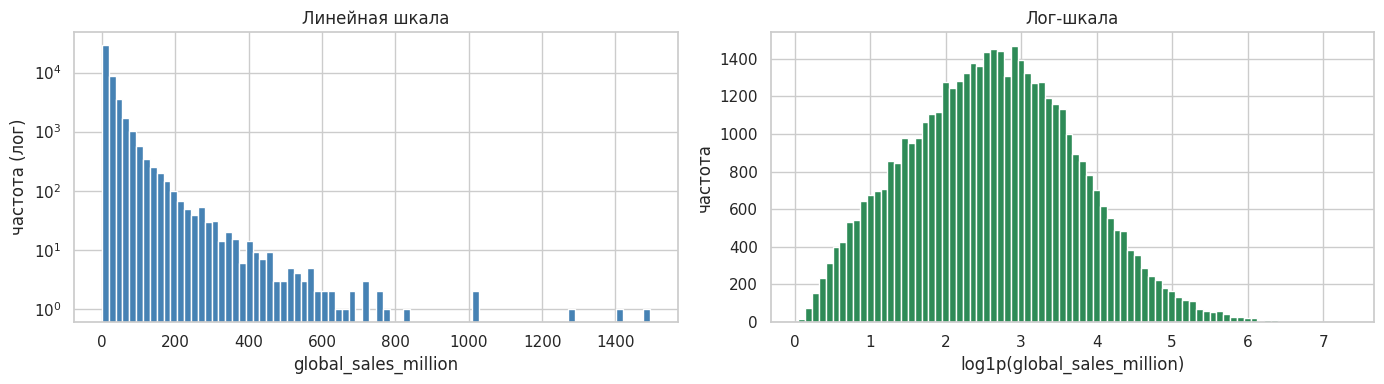

skew (линейная): 7.739
skew (log1p):    0.169


In [191]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Линейная шкала
axes[0].hist(df['global_sales_million'], bins=80, color='steelblue')
axes[0].set_yscale('log')
axes[0].set_xlabel('global_sales_million')
axes[0].set_ylabel('частота (лог)')
axes[0].set_title('Линейная шкала')

# Лог-шкала
axes[1].hist(np.log1p(df['global_sales_million']), bins=80, color='seagreen')
axes[1].set_xlabel('log1p(global_sales_million)')
axes[1].set_ylabel('частота')
axes[1].set_title('Лог-шкала')

plt.tight_layout()
plt.savefig('../eda/01_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'skew (линейная): {df["global_sales_million"].skew():.3f}')
print(f'skew (log1p):    {np.log1p(df["global_sales_million"]).skew():.3f}')

**Вывод:**
- Целевая переменная `global_sales_million` сильно смещена вправо (skew ≈ **7.74**): большинство игр продаются в диапазоне 5–30 млн копий, но присутствует длинный «хвост» из хитов-блокбастеров с продажами до ~1500 млн.
- После логарифмирования `log1p` распределение становится практически симметричным (skew ≈ **0.17**) и близким к нормальному.
- **Практический вывод:** для регрессии на сырых продажах метрики (RMSE/MAE) будут доминироваться выбросами. В ЛР2 имеет смысл обучать модель на `log1p(global_sales_million)` либо использовать устойчивые к выбросам функции потерь (Huber, quantile).

### 3.2. Продажи по типу платформы

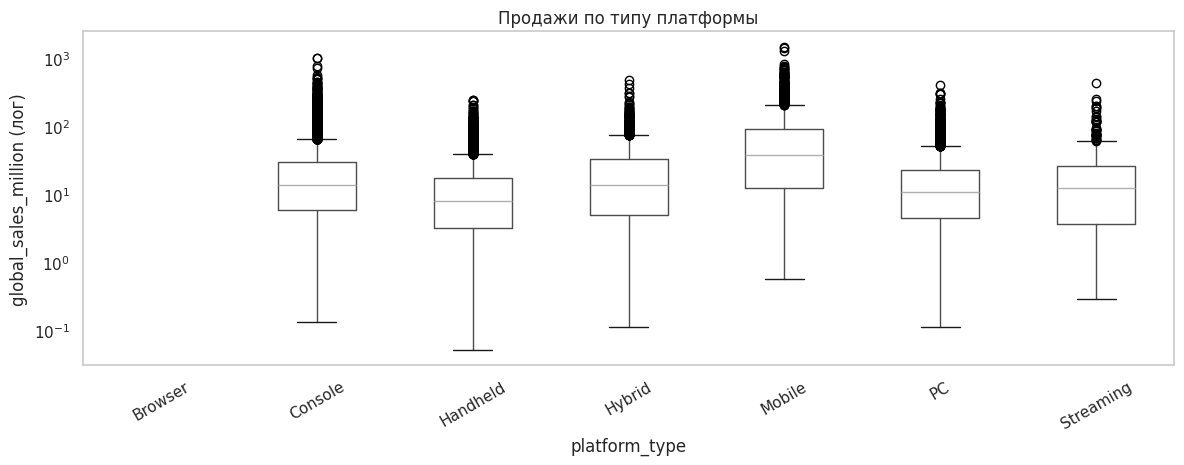

In [192]:
df.boxplot(column='global_sales_million', by='platform_type',
           figsize=(12, 5), grid=False)
plt.yscale('log')
plt.title('Продажи по типу платформы')
plt.suptitle('')
plt.xlabel('platform_type')
plt.ylabel('global_sales_million (лог)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../eda/02_sales_by_platform_type.png', dpi=100, bbox_inches='tight')
plt.show()

**Вывод:**
- Медианные продажи по типам платформ (`Console`, `Handheld`, `PC`, `Mobile`, `Hybrid`, `Streaming`) различаются, но ящики сильно перекрываются — разброс внутри каждой группы велик.
- Наиболее высокие медианы и «тяжёлые хвосты» наблюдаются у консольных и гибридных платформ; мобильные и браузерные платформы в среднем продаются скромнее, хотя среди них тоже встречаются хиты.
- **Практический вывод:** `platform_type` — полезный категориальный признак, но сам по себе он плохо разделяет данные. Для модели его стоит использовать в связке с жанром, издателем и годом.

### 3.3. Продажи по годам

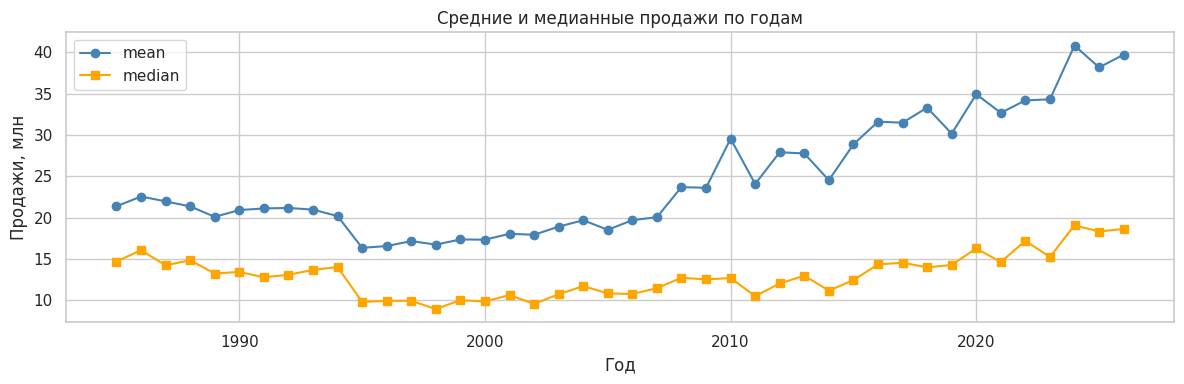

In [193]:
yearly = df.groupby('year')['global_sales_million'].agg(['mean', 'median', 'count'])

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(yearly.index, yearly['mean'], marker='o', label='mean', color='steelblue')
ax1.plot(yearly.index, yearly['median'], marker='s', label='median', color='orange')
ax1.set_xlabel('Год')
ax1.set_ylabel('Продажи, млн')
ax1.legend()
ax1.set_title('Средние и медианные продажи по годам')
plt.tight_layout()
plt.savefig('../eda/03_sales_by_year.png', dpi=100, bbox_inches='tight')
plt.show()

**Вывод:**
- Средние продажи заметно выше медианных на всём горизонте 1985–2026 — подтверждение сильной правосторонней асимметрии (влияние хитов).
- Медианные продажи относительно стабильны (~10–20 млн), тогда как средние колеблются и имеют пики в отдельные годы — следствие выхода крупных блокбастеров.
- Прослеживается общий тренд роста продаж с 1990-х к 2010-м и относительная стабилизация в 2010–2020-х.
- **Практический вывод:** `year` несёт информацию о временном тренде и должен быть включён в модель. Возможны производные признаки: «возраст игры», «поколение платформы».

### 3.4. Связь метакритика и продаж

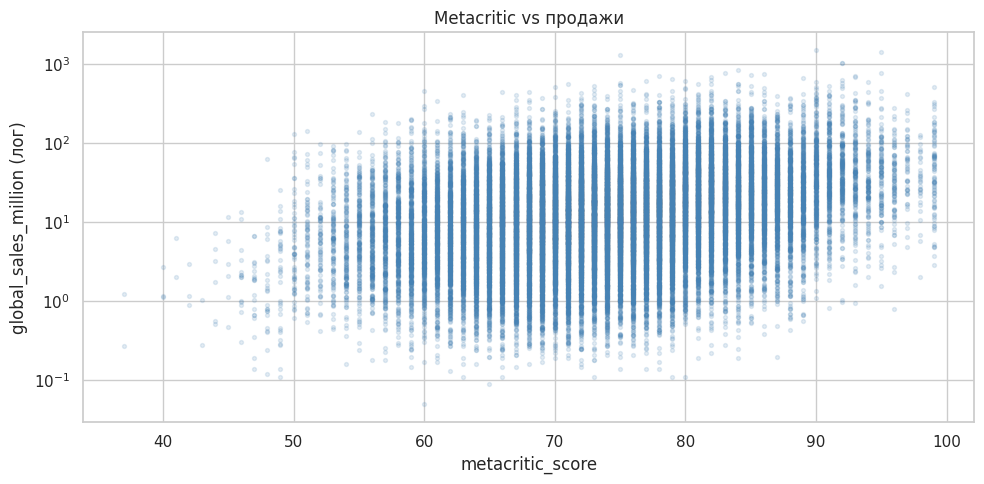

corr(metacritic, log_sales): 0.315
corr(user_score, log_sales): 0.229


In [194]:
plt.figure(figsize=(10, 5))
plt.scatter(df['metacritic_score'], df['global_sales_million'],
            alpha=0.15, s=8, color='steelblue')
plt.yscale('log')
plt.xlabel('metacritic_score')
plt.ylabel('global_sales_million (лог)')
plt.title('Metacritic vs продажи')
plt.tight_layout()
plt.savefig('../eda/04_metacritic_vs_sales.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'corr(metacritic, log_sales): '
      f'{df["metacritic_score"].corr(np.log1p(df["global_sales_million"])):.3f}')
print(f'corr(user_score, log_sales): '
      f'{df["user_score"].corr(np.log1p(df["global_sales_million"])):.3f}')

**Вывод:**
- Между оценкой критиков (`metacritic_score`) и логарифмом продаж наблюдается умеренная положительная корреляция (**≈ 0.315**); для `user_score` она слабее (**≈ 0.229**).
- При низких оценках (< 60) продажи почти всегда невелики, но при высоких (85+) разброс огромен — есть как хиты, так и скромные проекты.
- **Практический вывод:** оценки — значимые, но не определяющие предикторы. Их следует использовать вместе с издателем, жанром, платформой и маркетинговыми признаками.

### 3.5. Корреляции числовых признаков

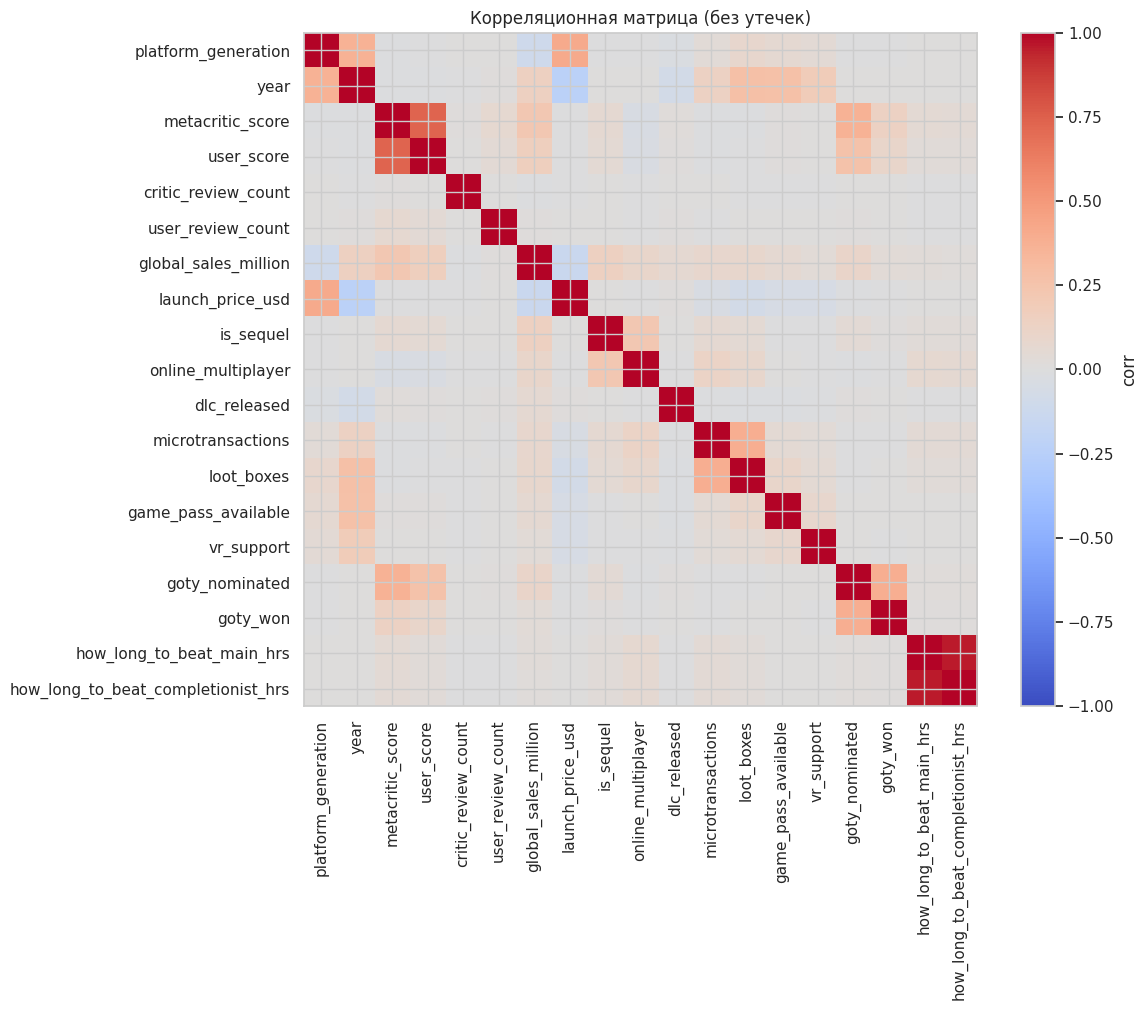

Топ-10 признаков по |corr| с целевой:
metacritic_score       0.224791
user_score             0.158700
is_sequel              0.142980
year                   0.141854
launch_price_usd       0.140086
platform_generation    0.105920
goty_nominated         0.104537
online_multiplayer     0.096719
loot_boxes             0.088671
microtransactions      0.083026
Name: global_sales_million, dtype: float64


In [195]:
# Только числовые, без утечек, чтобы не искажать картину
leak_cols = ['na_sales_million','eu_sales_million','jp_sales_million',
             'other_sales_million','estimated_revenue_million_usd']
corr_cols = [c for c in df.select_dtypes('number').columns if c not in leak_cols]
corr = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='corr')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Корреляционная матрица (без утечек)')
plt.tight_layout()
plt.savefig('../eda/05_corr_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Топ корреляций с целевой
target_corr = corr['global_sales_million'].drop('global_sales_million').abs().sort_values(ascending=False)
print('Топ-10 признаков по |corr| с целевой:')
print(target_corr.head(10))

**Вывод:**
- Все корреляции умеренные — ни один признак не доминирует. Это ожидаемо для продаж игр: они зависят от множества факторов.
- Региональные продажи (`na/eu/jp/other`) и `estimated_revenue_million_usd` исключены из матрицы как источник утечки данных.
- **Практический вывод:** для ЛР2 потребуется нелинейная модель (градиентный бустинг, случайный лес) — линейная регрессия на сырых признаках покажет скромное качество.

### 3.6. Интерактивный график: оценки критиков vs игроков

Исследуем, различаются ли жанры по согласованности оценок.

In [196]:
import plotly.express as px
import os
from IPython.display import HTML
from pathlib import Path

sample = df.sample(2000, random_state=42)  # меньше точек — быстрее SVG

fig = px.scatter(
    sample,
    x='metacritic_score',
    y='user_score',
    color='genre',
    hover_data=['platform', 'year', 'global_sales_million'],
    title='Metacritic vs User Score (жанры)',
    opacity=0.6,
)

# SVG-рендер вместо WebGL — работает в VS Code без WebGL
html_path = '/home/vboxuser/My_proj/eda/06_interactive_scores.html'
fig.write_html(html_path, include_plotlyjs='cdn')

size_mb = os.path.getsize(html_path) / 1024**2
print(f'✅ Сохранено: {html_path}  ({size_mb:.2f} MB)')

✅ Сохранено: /home/vboxuser/My_proj/eda/06_interactive_scores.html  (0.10 MB)


**Вывод:**
- Наблюдается отчётливая положительная **нелинейная** зависимость: при росте `metacritic_score` от 50 до 80 `user_score` растёт быстро (с ~5.5 до ~8), а после 85 — выходит на плато (~8–10). Это говорит о насыщении: дальнейшее улучшение оценок критиков почти не меняет восприятие игроков.
- При низких оценках критиков (< 60) разброс `user_score` максимален (4–8) — игроки иногда «прощают» слабые по мнению прессы проекты. При высоких (> 85) разброс, наоборот, сужается — консенсус.
- Жанры образуют перекрывающиеся кластеры, но есть смещения: например, **Simulation**, **Sports**, **Racing** чаще тяготеют к средним оценкам, а **Role-Playing**, **Action-Adventure**, **Shooter** — к высоким (80+ по метакритику).
- Заметны аномалии — точки с `metacritic_score > 85`, но `user_score < 6` (расхождение вкусов критиков и аудитории), и наоборот.
- **Практический вывод:** признаки `metacritic_score` и `user_score` несут разную информацию и должны использоваться в модели раздельно. Целесообразно добавить производный признак `critic_minus_user = metacritic_score/10 - user_score` — он прямо кодирует расхождение оценок и может улучшить качество регрессии.

In [197]:
import pickle

# Сохраняем очищенный датасет в pickle, чтобы сохранить типы столбцов
with open('../data/clean_dataset.pkl', 'wb') as f:
    pickle.dump(df, f)

print(f'Сохранено: ../data/clean_dataset.pkl')
print(f'Размер: {df.shape[0]} строк × {df.shape[1]} столбцов')

Сохранено: ../data/clean_dataset.pkl
Размер: 46032 строк × 33 столбцов
